In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
!wget -O creditcard.csv https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv

--2026-09-20 16:12:37--  https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.142.207, 74.125.195.207, 172.253.117.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.142.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 150828752 (144M) [text/csv]
Saving to: ‘creditcard.csv’

creditcard.csv      100%[===================>] 143.84M   218MB/s    in 0.7s    

2026-09-20 16:12:38 (218 MB/s) - ‘creditcard.csv’ saved [150828752/150828752]



In [4]:
df = pd.read_csv("creditcard.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 284807
Columns: 31


In [6]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [7]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [8]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [9]:
print(df["Class"].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


In [10]:
print(df["Class"].value_counts(normalize=True) * 100)

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


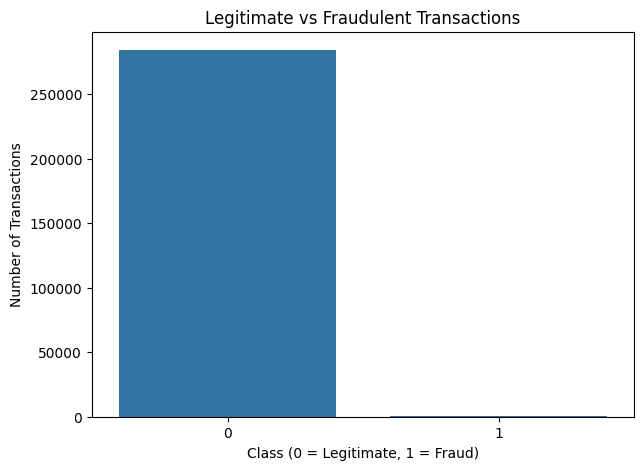

In [11]:
plt.figure(figsize=(7, 5))

sns.countplot(x="Class", data=df)

plt.title("Legitimate vs Fraudulent Transactions")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Number of Transactions")

plt.show()

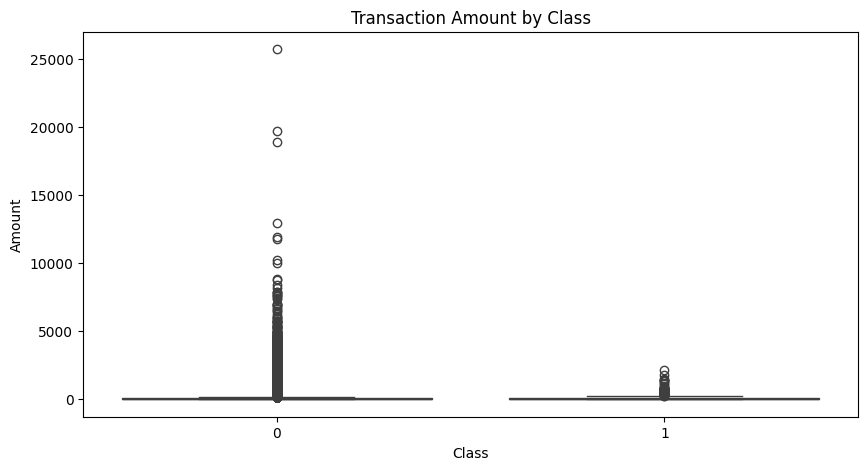

In [12]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    x="Class",
    y="Amount",
    data=df
)

plt.title("Transaction Amount by Class")
plt.xlabel("Class")
plt.ylabel("Amount")

plt.show()

In [13]:
df["Amount_log"] = np.log1p(df["Amount"])

print("Amount_log created successfully!")

Amount_log created successfully!


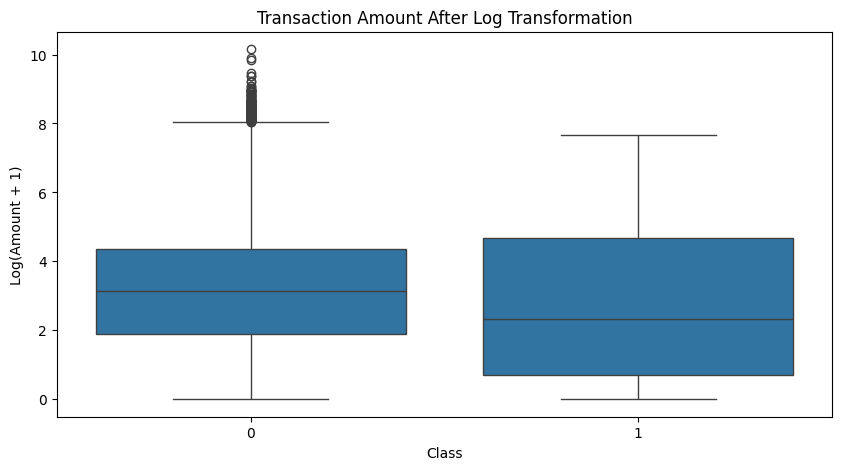

In [14]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    x="Class",
    y="Amount_log",
    data=df
)

plt.title("Transaction Amount After Log Transformation")
plt.xlabel("Class")
plt.ylabel("Log(Amount + 1)")

plt.show()

In [15]:
correlation = df.corr(numeric_only=True)["Class"].sort_values()

print(correlation)

V17          -0.326481
V14          -0.302544
V12          -0.260593
V10          -0.216883
V16          -0.196539
V3           -0.192961
V7           -0.187257
V18          -0.111485
V1           -0.101347
V9           -0.097733
V5           -0.094974
V6           -0.043643
Time         -0.012323
Amount_log   -0.008326
V24          -0.007221
V13          -0.004570
V15          -0.004223
V23          -0.002685
V22           0.000805
V25           0.003308
V26           0.004455
Amount        0.005632
V28           0.009536
V27           0.017580
V8            0.019875
V20           0.020090
V19           0.034783
V21           0.040413
V2            0.091289
V4            0.133447
V11           0.154876
Class         1.000000
Name: Class, dtype: float64


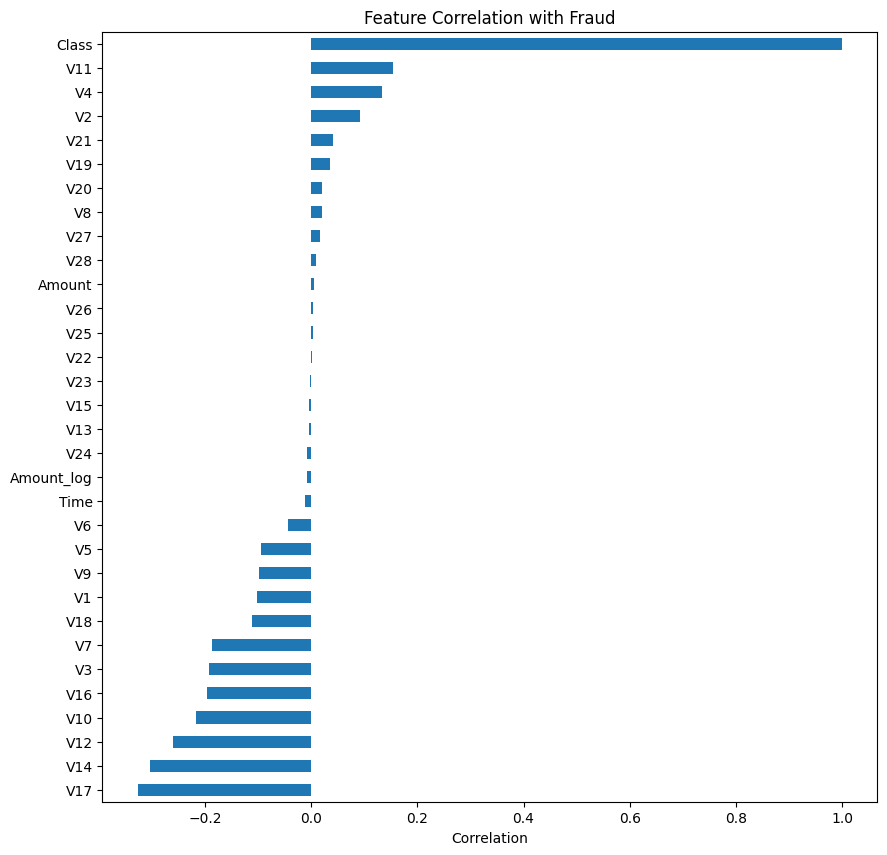

In [16]:
plt.figure(figsize=(10, 10))

correlation.sort_values().plot(kind="barh")

plt.title("Feature Correlation with Fraud")
plt.xlabel("Correlation")

plt.show()

In [17]:
X = df.drop(["Class", "Amount_log"], axis=1)
y = df["Class"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (284807, 30)
y shape: (284807,)


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (227845, 30)
Testing data: (56962, 30)


In [19]:
print("Training data:")
print(y_train.value_counts())

print("\nTesting data:")
print(y_test.value_counts())

Training data:
Class
0    227451
1       394
Name: count, dtype: int64

Testing data:
Class
0    56864
1       98
Name: count, dtype: int64


In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


In [21]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


In [22]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_smote,
    y_train_smote
)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [23]:
y_pred_lr = logistic_model.predict(X_test_scaled)

y_prob_lr = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("Predictions completed!")

Predictions completed!


In [24]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_lr))
print("PR-AUC   :", average_precision_score(y_test, y_prob_lr))

Accuracy : 0.9741055440469084
Precision: 0.057803468208092484
Recall   : 0.9183673469387755
F1 Score : 0.10876132930513595
ROC-AUC  : 0.9708434302252134
PR-AUC   : 0.7244694356694709


In [25]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_lr
))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



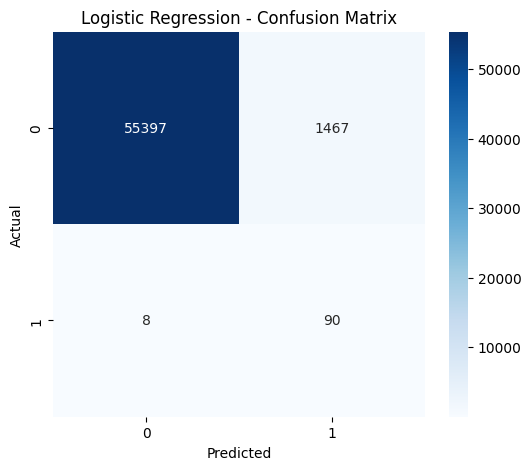

In [26]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [29]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=30,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

print("Starting Random Forest training...")

rf_model.fit(
    X_train_smote,
    y_train_smote
)

print("Random Forest trained successfully!")

Starting Random Forest training...
Random Forest trained successfully!


In [30]:
y_pred_rf = rf_model.predict(X_test_scaled)

y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print("Predictions completed!")

Predictions completed!


In [31]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf))
print("PR-AUC   :", average_precision_score(y_test, y_prob_rf))

Accuracy : 0.9985253326779256
Precision: 0.5448717948717948
Recall   : 0.8673469387755102
F1 Score : 0.6692913385826772
ROC-AUC  : 0.9747458669736887
PR-AUC   : 0.836513831436066


In [32]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.54      0.87      0.67        98

    accuracy                           1.00     56962
   macro avg       0.77      0.93      0.83     56962
weighted avg       1.00      1.00      1.00     56962



In [35]:
y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print("Random Forest predictions completed!")

Random Forest predictions completed!


In [36]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf))
print("PR-AUC   :", average_precision_score(y_test, y_prob_rf))

Accuracy : 0.9985253326779256
Precision: 0.5448717948717948
Recall   : 0.8673469387755102
F1 Score : 0.6692913385826772
ROC-AUC  : 0.9747458669736887
PR-AUC   : 0.836513831436066


In [37]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.54      0.87      0.67        98

    accuracy                           1.00     56962
   macro avg       0.77      0.93      0.83     56962
weighted avg       1.00      1.00      1.00     56962



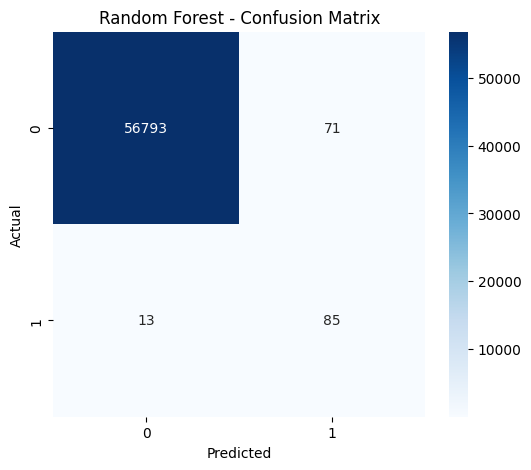

In [38]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [39]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf))
print("PR-AUC   :", average_precision_score(y_test, y_prob_rf))

Accuracy : 0.9985253326779256
Precision: 0.5448717948717948
Recall   : 0.8673469387755102
F1 Score : 0.6692913385826772
ROC-AUC  : 0.9747458669736887
PR-AUC   : 0.836513831436066


In [40]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf)
    ],
    "PR-AUC": [
        average_precision_score(y_test, y_prob_lr),
        average_precision_score(y_test, y_prob_rf)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.974106,0.057803,0.918367,0.108761,0.970843,0.724469
1,Random Forest,0.998525,0.544872,0.867347,0.669291,0.974746,0.836514


In [42]:
from google.colab import sheets
from google.colab import auth

auth.authenticate_user()
sheet = sheets.InteractiveSheet(df=results)

https://docs.google.com/spreadsheets/d/1PeqdFzDZFK4KIN_wQvXU_iaAO4yOattPbspWU-D8Ors/edit#gid=0


In [43]:
# Model Comparison

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],

    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],

    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf)
    ],

    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ],

    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf)
    ],

    "PR-AUC": [
        average_precision_score(y_test, y_prob_lr),
        average_precision_score(y_test, y_prob_rf)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.974106,0.057803,0.918367,0.108761,0.970843,0.724469
1,Random Forest,0.998525,0.544872,0.867347,0.669291,0.974746,0.836514


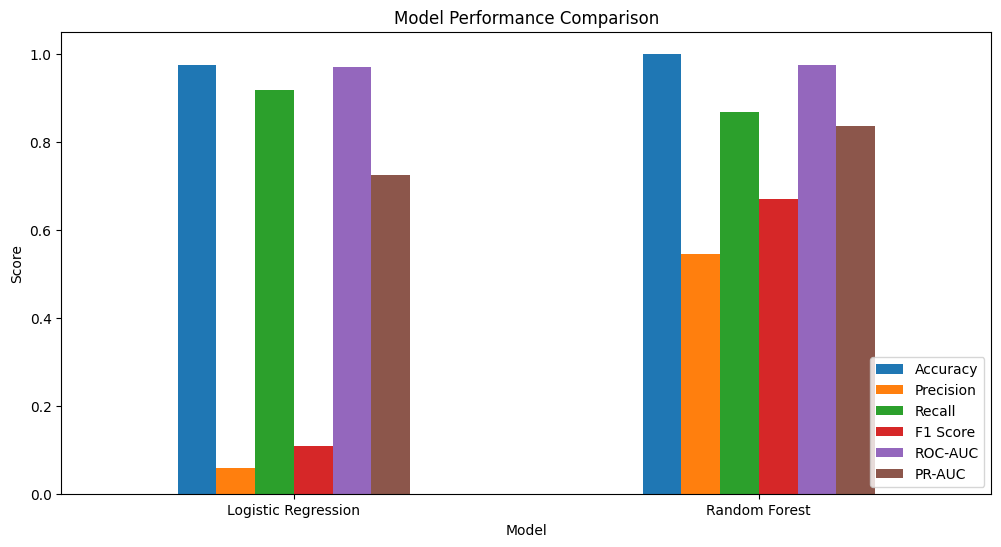

In [46]:
comparison.set_index("Model").plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

In [47]:
import joblib

print("Joblib imported successfully!")

Joblib imported successfully!


In [48]:
joblib.dump(rf_model, "fraud_detection_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [49]:
joblib.dump(scaler, "scaler.pkl")

print("Scaler saved successfully!")

Scaler saved successfully!


In [50]:
import os

print("fraud_detection_model.pkl exists:",
      os.path.exists("fraud_detection_model.pkl"))

print("scaler.pkl exists:",
      os.path.exists("scaler.pkl"))

fraud_detection_model.pkl exists: True
scaler.pkl exists: True


In [51]:
from google.colab import files

files.download("fraud_detection_model.pkl")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [52]:
sample = X_test.iloc[0].values.reshape(1, -1)

print("Sample transaction selected!")
print("Shape:", sample.shape)

Sample transaction selected!
Shape: (1, 30)


In [53]:
sample_scaled = scaler.transform(sample)

print("Transaction scaled successfully!")

Transaction scaled successfully!


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [54]:
prediction = rf_model.predict(sample_scaled)[0]
probability = rf_model.predict_proba(sample_scaled)[0][1]

if prediction == 1:
    print("🚨 FRAUDULENT TRANSACTION")
else:
    print("✅ LEGITIMATE TRANSACTION")

print("Fraud probability:", round(probability * 100, 2), "%")

✅ LEGITIMATE TRANSACTION
Fraud probability: 1.59 %


In [55]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib

# Load trained model and scaler
model = joblib.load("fraud_detection_model.pkl")
scaler = joblib.load("scaler.pkl")

# Page configuration
st.set_page_config(
    page_title="Credit Card Fraud Detection",
    page_icon="💳",
    layout="centered"
)

st.title("💳 Credit Card Fraud Detection")
st.write("Machine Learning based fraud detection system")

st.divider()

st.subheader("Enter Transaction Details")

# Basic transaction information
time = st.number_input(
    "Transaction Time",
    min_value=0.0,
    value=0.0
)

amount = st.number_input(
    "Transaction Amount",
    min_value=0.0,
    value=100.0
)

st.subheader("Transaction Features")

features = []

for i in range(1, 29):
    value = st.number_input(
        f"V{i}",
        value=0.0
    )
    features.append(value)

st.divider()

if st.button("🔍 Check Transaction", use_container_width=True):

    transaction = [time] + features + [amount]

    transaction_df = pd.DataFrame(
        [transaction],
        columns=["Time"] +
                [f"V{i}" for i in range(1, 29)] +
                ["Amount"]
    )

    # Scale input
    transaction_scaled = scaler.transform(transaction_df)

    # Prediction
    prediction = model.predict(transaction_scaled)[0]
    probability = model.predict_proba(transaction_scaled)[0][1]

    st.subheader("Prediction Result")

    if prediction == 1:
        st.error("🚨 FRAUDULENT TRANSACTION")
    else:
        st.success("✅ LEGITIMATE TRANSACTION")

    st.metric(
        "Fraud Probability",
        f"{probability * 100:.2f}%"
    )

Writing app.py


In [56]:
%%writefile requirements.txt

pandas
numpy
scikit-learn
imbalanced-learn
matplotlib
seaborn
streamlit
joblib

Writing requirements.txt


In [57]:
import os

print("Project files:")

for file in os.listdir():
    if file.endswith((".py", ".pkl", ".txt")):
        print("✅", file)

Project files:
✅ requirements.txt
✅ fraud_detection_model.pkl
✅ scaler.pkl
✅ app.py


In [58]:
!pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 70.7 MB/s eta 0:00:00


In [59]:
!streamlit run app.py &>/content/logs.txt &

print("Streamlit server started!")

Streamlit server started!


In [60]:
!wget -q -O - http://localhost:8501

<!--
 Copyright (c) Streamlit Inc. (2018-2022) Snowflake Inc. (2022-2026)

 Licensed under the Apache License, Version 2.0 (the "License");
 you may not use this file except in compliance with the License.
 You may obtain a copy of the License at

     http://www.apache.org/licenses/LICENSE-2.0

 Unless required by applicable law or agreed to in writing, software
 distributed under the License is distributed on an "AS IS" BASIS,
 WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
 See the License for the specific language governing permissions and
 limitations under the License.
-->

<!DOCTYPE html>
<html lang="en">
  <head>
    <meta charset="UTF-8" />
    <meta
      name="viewport"
      content="width=device-width, initial-scale=1, shrink-to-fit=no"
    />
    <link rel="shortcut icon" href="./favicon.png" />
    <link
      rel="preload"
      href="./static/media/SourceSansVF-Upright.ttf.BsWL4Kly.woff2"
      as="font"
      type="font/woff2"
      crossorig

In [65]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb

Selecting previously unselected package cloudflared.
(Reading database ... 122809 files and directories currently installed.)
Preparing to unpack cloudflared-linux-amd64.deb ...
Unpacking cloudflared (2026.9.1) ...
Setting up cloudflared (2026.9.1) ...
Processing triggers for man-db (2.12.0-4build2) ...


In [66]:
import subprocess
import time

process = subprocess.Popen(
    ["cloudflared", "tunnel", "--url", "http://localhost:8501"],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

time.sleep(5)

for _ in range(20):
    line = process.stdout.readline()
    if line:
        print(line.strip())

2026-09-20T17:06:28Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-09-20T17:06:28Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-09-20T17:06:32Z INF +--------------------------------------------------------------------------------------------+
2026-09-20T17:06:32Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-09-20T17:06:32Z INF |  https://taxes-seeks-excessive-acceptable.trycloudflar

In [67]:
from google.colab import files

files.download("app.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [68]:
files.download("requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>